In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
df = pd.read_csv("C:/Users/User/OneDrive/Desktop/My CV Project 1/Diabetes Data Set/diabetic_data.csv")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
print(f'Shape: {df.shape}')

Shape: (101766, 50)


In [4]:
print(df.dtypes)

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

In [5]:
print(df['readmitted'].value_counts())

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


In [6]:
print(f'Percentage:{df['readmitted'].value_counts(normalize=True).mul(100).round(1)}')

Percentage:readmitted
NO     53.9
>30    34.9
<30    11.2
Name: proportion, dtype: float64


In [7]:
df.replace('?', np.nan, inplace=True) # Replace ? with NaN 

In [8]:
missing = (df.isnull().mean() * 100).round(2)
print('Missing values (%) per column:')
print(missing[missing > 0].sort_values(ascending=False))

Missing values (%) per column:
weight               96.86
max_glu_serum        94.75
A1Cresult            83.28
medical_specialty    49.08
payer_code           39.56
race                  2.23
diag_3                1.40
diag_2                0.35
diag_1                0.02
dtype: float64


In [9]:
# Drop columns with >40% missing + IDs + irrelevant
drop_cols = ['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty',
             'payer_code', 'encounter_id', 'patient_nbr',
             'diag_3', 'diag_2', 'diag_1']

df.drop(columns=drop_cols, inplace=True)

In [10]:
# Drop remaining rows with NaN
df.dropna(inplace=True)


In [11]:
# Remove invalid gender
df = df[df['gender'] != 'Unknown/Invalid']

In [12]:
print(f'Shape after cleaning: {df.shape}')

Shape after cleaning: (99492, 40)


In [13]:
# Binary encode target: <30 = 1 (early readmission), else 0
df['readmitted'] = (df['readmitted'] == '<30').astype(int)
print('Target distribution after encoding:')
print(df['readmitted'].value_counts())
print(f'\nEarly readmission rate: {df["readmitted"].mean()*100:.1f}%')

Target distribution after encoding:
readmitted
0    88323
1    11169
Name: count, dtype: int64

Early readmission rate: 11.2%


## Visualizations

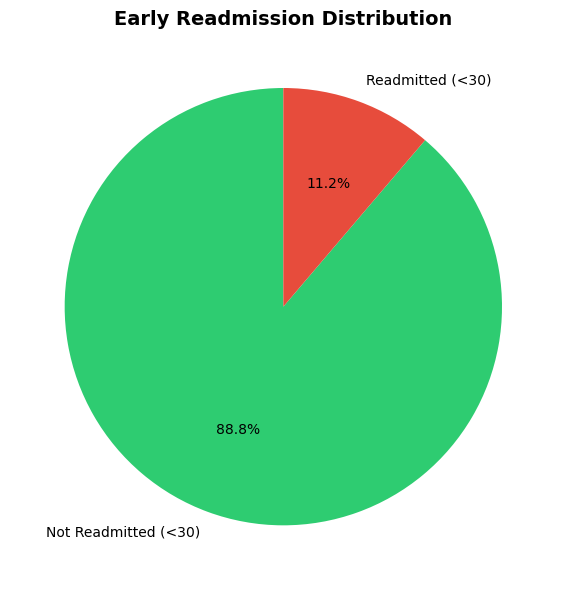

In [14]:
# 1. Readmission Distribution
fig, ax = plt.subplots(figsize=(6, 6))

counts = df['readmitted'].value_counts()

ax.pie(counts, labels=['Not Readmitted (<30)', 'Readmitted (<30)'],
       autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)

ax.set_title('Early Readmission Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

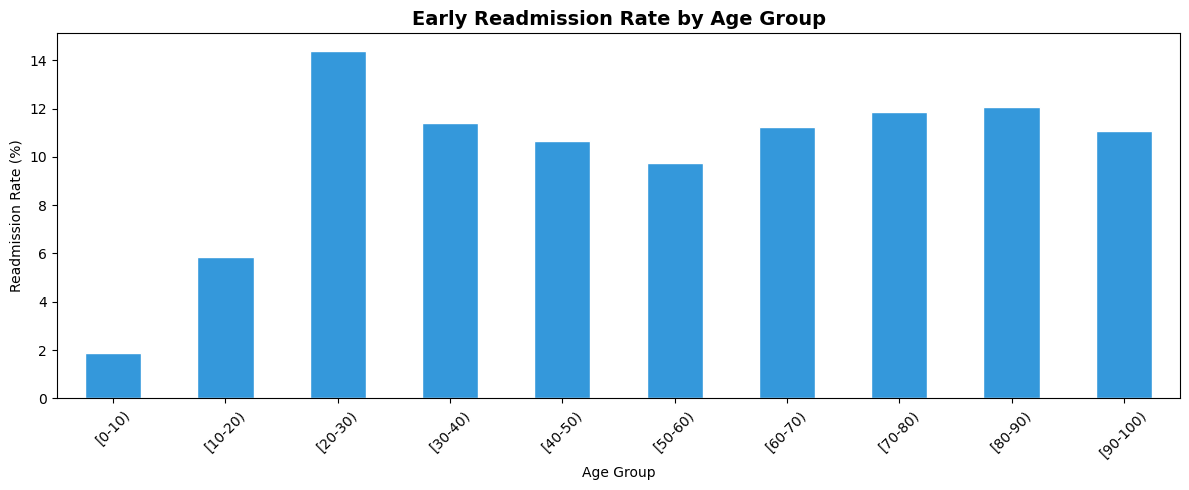

In [15]:
# 2. Readmission Rate by Age Group
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
age_churn = df.groupby('age')['readmitted'].mean().reindex(age_order) * 100

fig, ax = plt.subplots(figsize=(12, 5))

age_churn.plot(kind='bar', ax=ax, color='#3498db', edgecolor='white')

ax.set_title('Early Readmission Rate by Age Group', fontsize=14, fontweight='bold')

ax.set_xlabel('Age Group')
ax.set_ylabel('Readmission Rate (%)')

ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

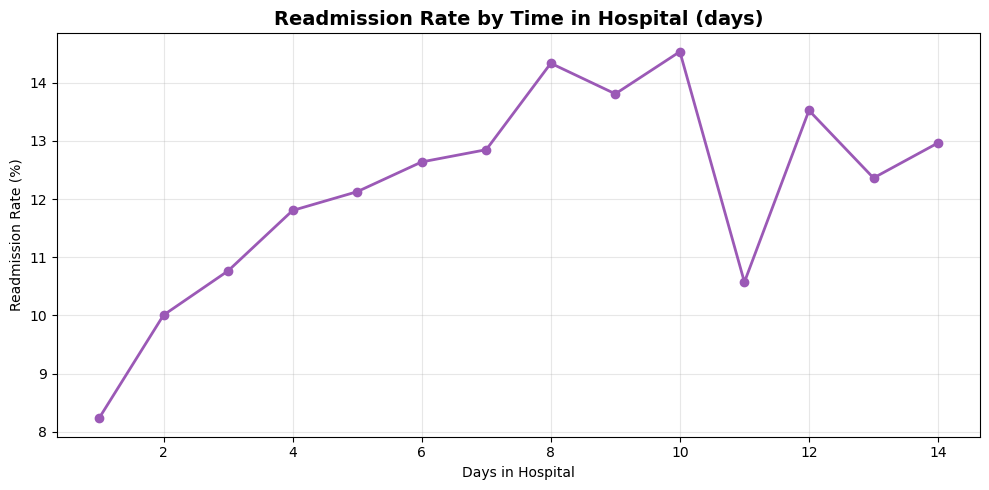

In [16]:
# 3. Readmission Rate by Time in Hospital
time_readmit = df.groupby('time_in_hospital')['readmitted'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(time_readmit.index, time_readmit.values, marker='o', color='#9b59b6', linewidth=2)

ax.set_title('Readmission Rate by Time in Hospital (days)', fontsize=14, fontweight='bold')

ax.set_xlabel('Days in Hospital')
ax.set_ylabel('Readmission Rate (%)')

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

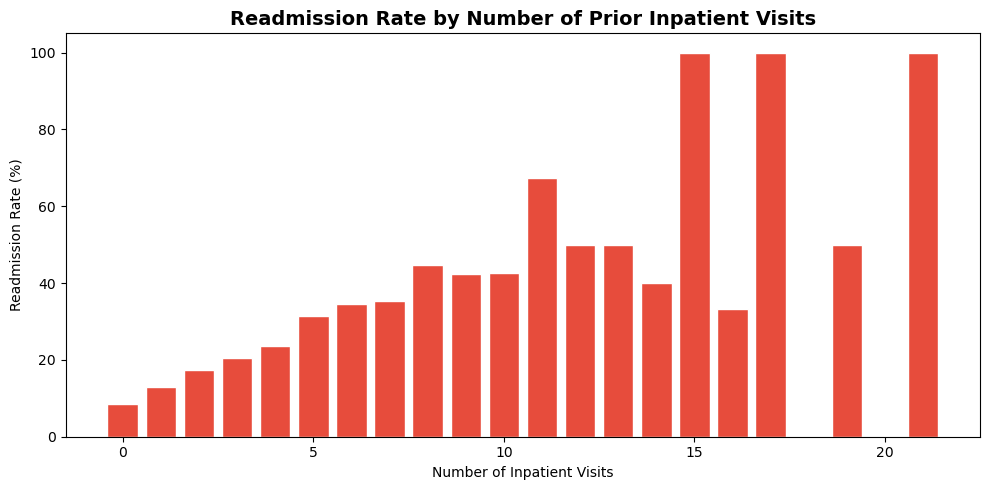

In [17]:
# 4. Readmission by Number of Inpatient Visits
inpatient = df.groupby('number_inpatient')['readmitted'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(inpatient.index, inpatient.values, color='#e74c3c', edgecolor='white')

ax.set_title('Readmission Rate by Number of Prior Inpatient Visits', fontsize=14, fontweight='bold')

ax.set_xlabel('Number of Inpatient Visits')
ax.set_ylabel('Readmission Rate (%)')

plt.tight_layout()
plt.show()

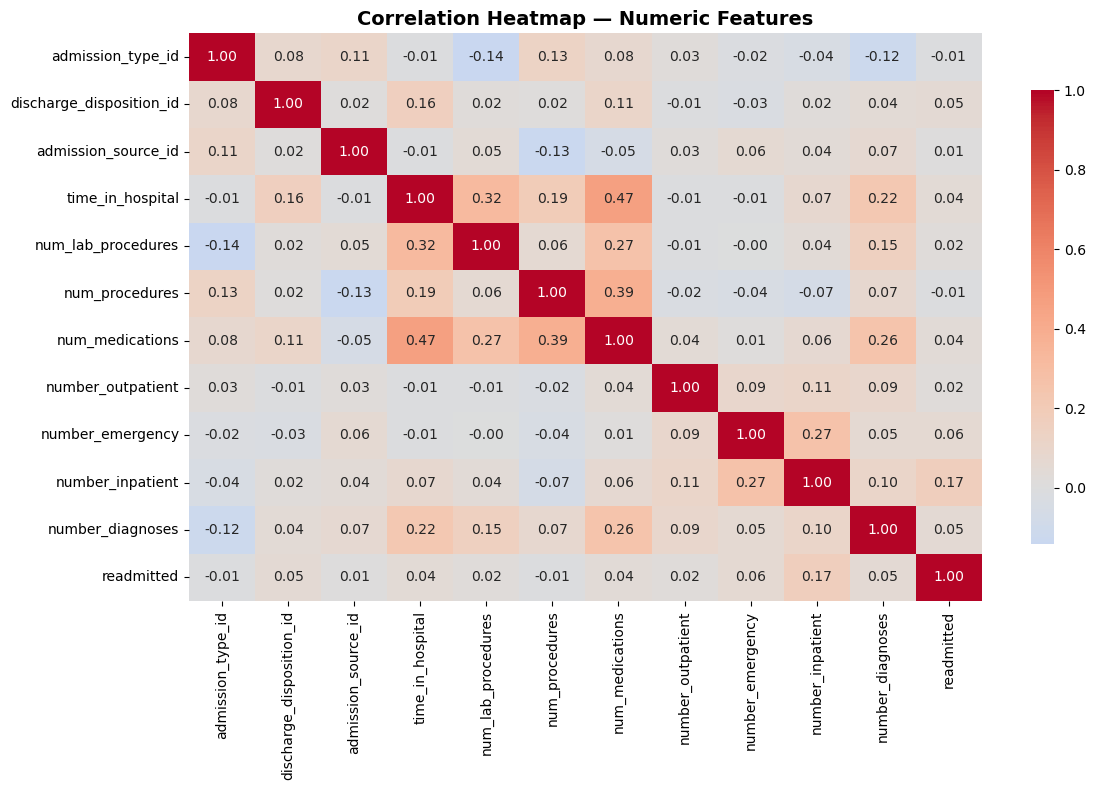

In [18]:
# 5. Correlation Heatmap (numeric features)
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, cbar_kws={'shrink': 0.8})

ax.set_title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

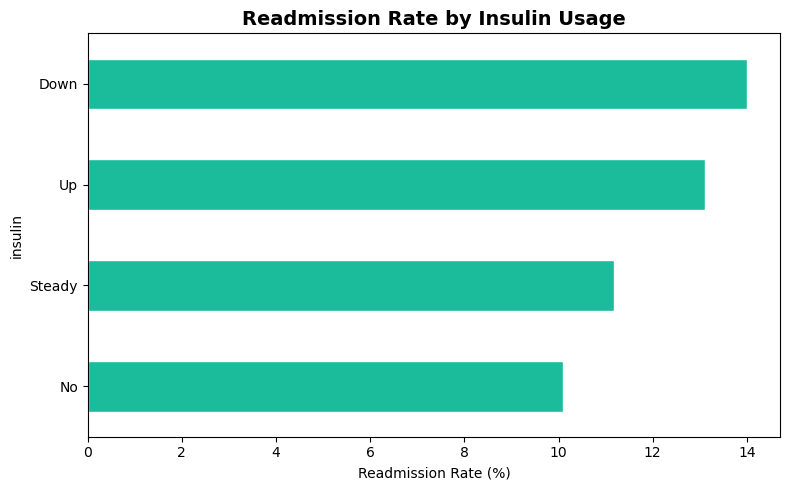

In [19]:
# 6. Readmission Rate by Insulin Usage
insulin_rate = df.groupby('insulin')['readmitted'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))

insulin_rate.sort_values().plot(kind='barh', ax=ax, color='#1abc9c', edgecolor='white')

ax.set_title('Readmission Rate by Insulin Usage', fontsize=14, fontweight='bold')
ax.set_xlabel('Readmission Rate (%)')

plt.tight_layout()
plt.show()

## Preprocessing


In [20]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [21]:
# Ordinal encode age
age_map = {'[0-10)':0,'[10-20)':1,'[20-30)':2,'[30-40)':3,'[40-50)':4,
           '[50-60)':5,'[60-70)':6,'[70-80)':7,'[80-90)':8,'[90-100)':9}
df['age'] = df['age'].map(age_map)

In [22]:
# Label encode binary columns
binary_cols = ['gender', 'change', 'diabetesMed']
for col in binary_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

In [23]:
# One-hot encode race and admission type
df = pd.get_dummies(df, columns=['race'], drop_first=True)

In [24]:
# Encode remaining string columns (medication columns)
med_cols = df.select_dtypes(include='object').columns.tolist()
for col in med_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

In [25]:
print(f'Shape after preprocessing: {df.shape}')
print(f'Any remaining nulls: {df.isnull().sum().sum()}')

Shape after preprocessing: (99492, 43)
Any remaining nulls: 0


In [26]:
# Scale numeric columns
scaler = StandardScaler()

scale_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
              'num_medications', 'number_outpatient', 'number_emergency',
              'number_inpatient', 'number_diagnoses']

df[scale_cols] = scaler.fit_transform(df[scale_cols])

df.head()

,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,...,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,race_Asian,race_Caucasian,race_Hispanic,race_Other
0,0,0,6,25,1,-1.137765,-0.105251,-0.786851,-1.850613,-0.292416,...,0,0,0,1,0,0,False,True,False,False
1,0,1,1,1,7,-0.468187,0.808664,-0.786851,0.243043,-0.292416,...,0,0,0,0,1,0,False,True,False,False
2,0,2,1,1,7,-0.802976,-1.628443,2.147977,-0.372738,1.274002,...,0,0,0,1,1,0,False,False,False,False
3,1,3,1,1,7,-0.802976,0.047068,-0.199885,-0.003269,-0.292416,...,0,0,0,0,1,0,False,True,False,False
4,1,4,1,1,7,-1.137765,0.402479,-0.786851,-0.988519,-0.292416,...,0,0,0,0,1,0,False,True,False,False


## Model Building

### Logistic Regression

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [28]:
# Split data
X = df.drop('readmitted', axis=1)
y = df['readmitted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train size: {X_train.shape}')
print(f'Test size:  {X_test.shape}')
print(f'Class balance in train: {y_train.value_counts().to_dict()}')

# Train Logistic Regression
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]

print('Logistic Regression training complete.')

Train size: (79593, 42)
Test size:  (19899, 42)
Class balance in train: {0: 70658, 1: 8935}
Logistic Regression training complete.


In [29]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_lr, target_names=['Not Readmitted', 'Readmitted']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}')

                precision    recall  f1-score   support

Not Readmitted       0.89      1.00      0.94     17665
    Readmitted       0.49      0.02      0.03      2234

      accuracy                           0.89     19899
     macro avg       0.69      0.51      0.49     19899
  weighted avg       0.84      0.89      0.84     19899

ROC-AUC: 0.6364


In [30]:
model_lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lr, target_names=['Not Readmitted', 'Readmitted']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}')

                precision    recall  f1-score   support

Not Readmitted       0.92      0.69      0.79     17665
    Readmitted       0.17      0.51      0.25      2234

      accuracy                           0.67     19899
     macro avg       0.54      0.60      0.52     19899
  weighted avg       0.83      0.67      0.73     19899

ROC-AUC: 0.6374


### Random Forest

In [31]:
from sklearn.ensemble import RandomForestClassifier

In [32]:
# Train Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, 
                                   n_jobs=-1, class_weight='balanced')
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=['Not Readmitted', 'Readmitted']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}')

                precision    recall  f1-score   support

Not Readmitted       0.89      1.00      0.94     17665
    Readmitted       0.30      0.00      0.01      2234

      accuracy                           0.89     19899
     macro avg       0.59      0.50      0.47     19899
  weighted avg       0.82      0.89      0.84     19899

ROC-AUC: 0.6274


In [33]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42,
                                   n_jobs=-1, class_weight='balanced',
                                   min_samples_leaf=5)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=['Not Readmitted', 'Readmitted']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}')

                precision    recall  f1-score   support

Not Readmitted       0.90      0.94      0.92     17665
    Readmitted       0.27      0.17      0.21      2234

      accuracy                           0.85     19899
     macro avg       0.58      0.56      0.56     19899
  weighted avg       0.83      0.85      0.84     19899

ROC-AUC: 0.6502


### Gradient Boosting

In [34]:
from sklearn.ensemble import GradientBoostingClassifier

In [35]:
# Train Gradient Boosting
model_gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
model_gb.fit(X_train, y_train)

y_pred_gb = model_gb.predict(X_test)
y_prob_gb = model_gb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_gb, target_names=['Not Readmitted', 'Readmitted']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_gb):.4f}')

                precision    recall  f1-score   support

Not Readmitted       0.89      1.00      0.94     17665
    Readmitted       0.55      0.01      0.02      2234

      accuracy                           0.89     19899
     macro avg       0.72      0.51      0.48     19899
  weighted avg       0.85      0.89      0.84     19899

ROC-AUC: 0.6661


In [36]:
# Calculate class weight manually
scale = len(y_train[y_train==0]) / len(y_train[y_train==1])
print(f'Scale weight: {scale:.2f}')

model_gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
model_gb.fit(X_train, y_train, sample_weight=[scale if v==1 else 1 for v in y_train])

y_pred_gb = model_gb.predict(X_test)
y_prob_gb = model_gb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_gb, target_names=['Not Readmitted', 'Readmitted']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_gb):.4f}')

Scale weight: 7.91
                precision    recall  f1-score   support

Not Readmitted       0.93      0.64      0.75     17665
    Readmitted       0.17      0.59      0.27      2234

      accuracy                           0.63     19899
     macro avg       0.55      0.61      0.51     19899
  weighted avg       0.84      0.63      0.70     19899

ROC-AUC: 0.6639


### Visualization for these three models

In [37]:
from sklearn.metrics import confusion_matrix, roc_curve, average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

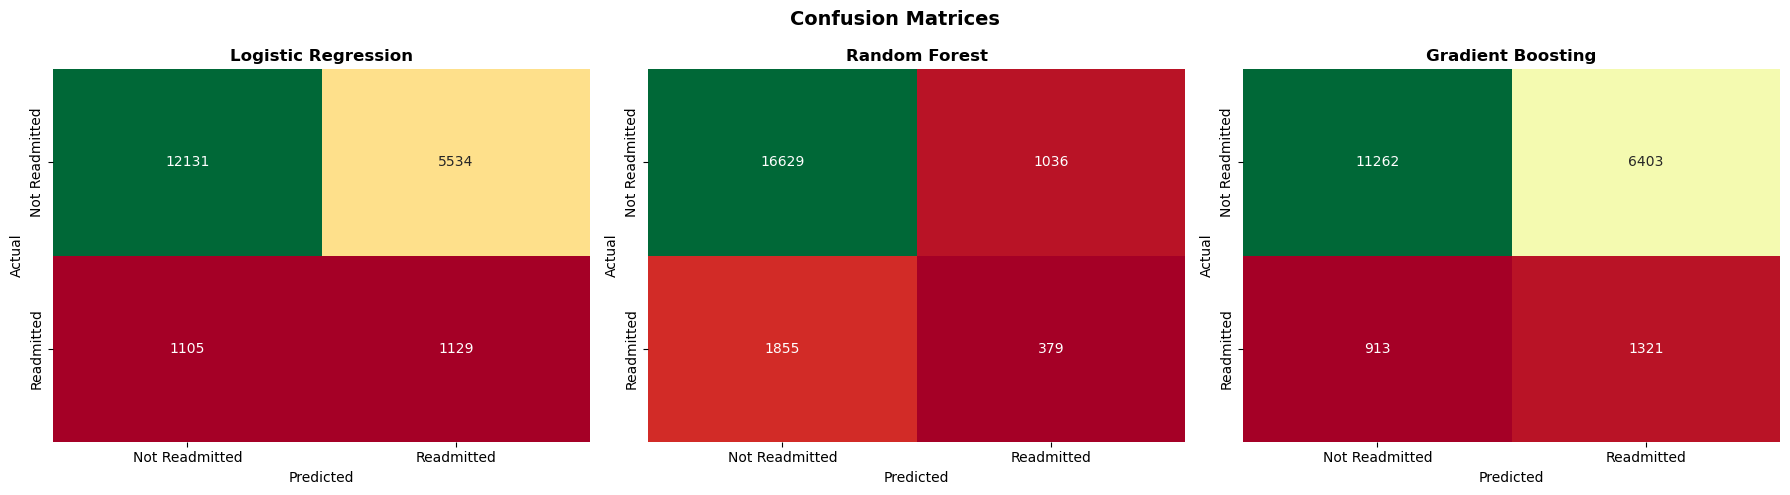

In [38]:
# 1.Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_eval = {
    'Logistic Regression': (y_pred_lr, y_prob_lr),
    'Random Forest':       (y_pred_rf, y_prob_rf),
    'Gradient Boosting':   (y_pred_gb, y_prob_gb)
}

for ax, (name, (y_pred, y_prob)) in zip(axes, models_eval.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='RdYlGn', cbar=False,
                xticklabels=['Not Readmitted', 'Readmitted'],
                yticklabels=['Not Readmitted', 'Readmitted'])
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

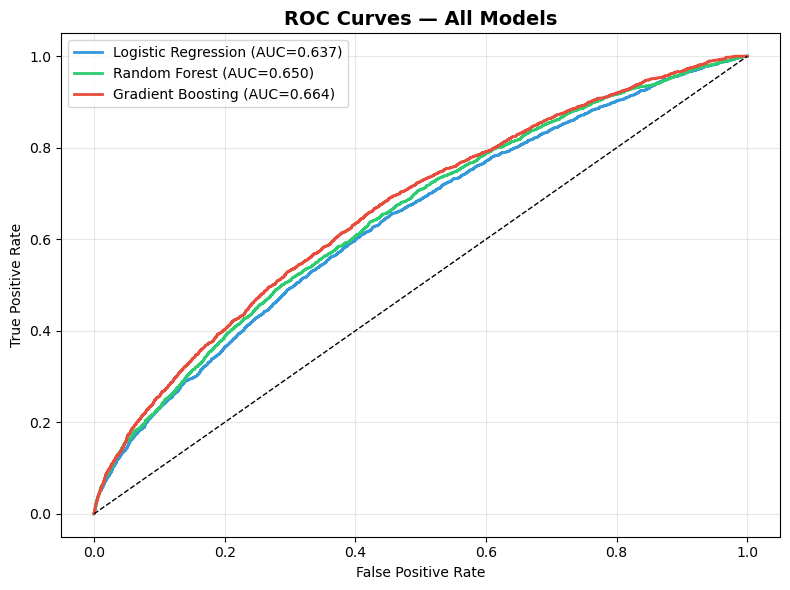

In [39]:
# 2.ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c']

for (name, (y_pred, y_prob)), color in zip(models_eval.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

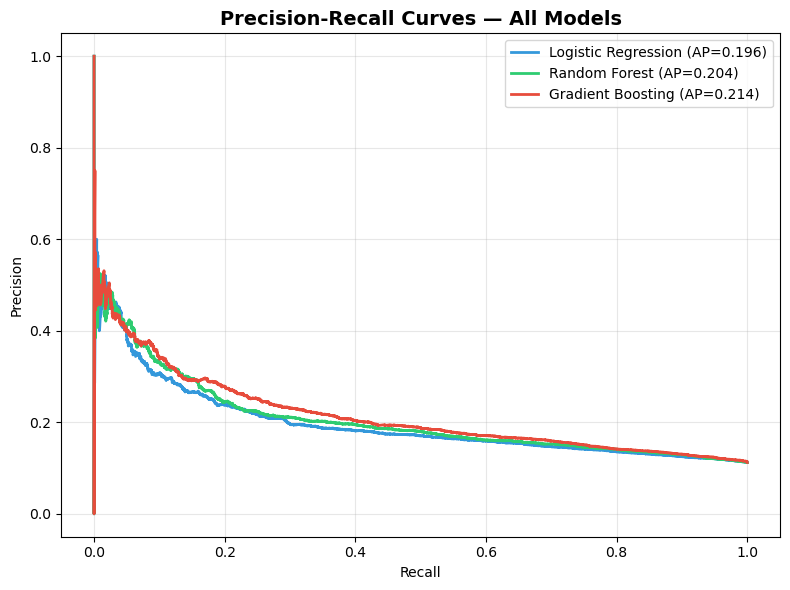

In [40]:
# 3.Precision-Recall Curves
fig, ax = plt.subplots(figsize=(8, 6))

for (name, (y_pred, y_prob)), color in zip(models_eval.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(rec, prec, color=color, lw=2, label=f'{name} (AP={ap:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — All Models', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Feature Importance

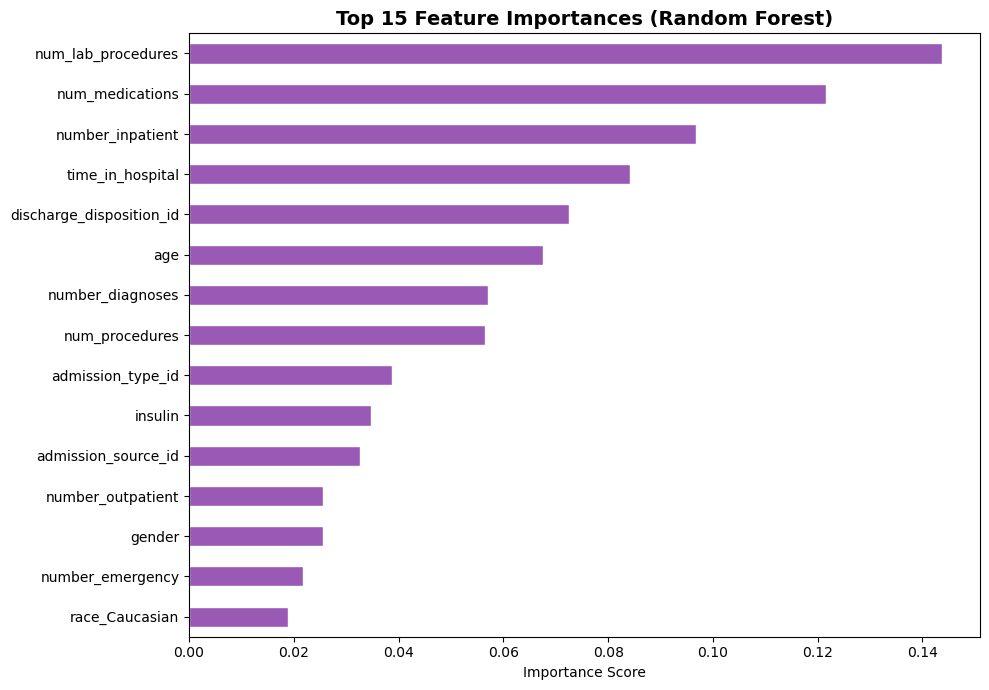

Top 5 features driving readmission:
discharge_disposition_id    0.072612
time_in_hospital            0.084250
number_inpatient            0.096742
num_medications             0.121639
num_lab_procedures          0.143797
dtype: float64


In [42]:
## Random Forecast Feature Importance
feat_imp = pd.Series(model_rf.feature_importances_, index=X.columns).nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
feat_imp.plot(kind='barh', ax=ax, color='#9b59b6', edgecolor='white')
ax.set_title('Top 15 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 features driving readmission:')
print(feat_imp.tail(5))


## Conclusions

### Model Performance Summary

| Model | Accuracy | Readmitted Recall | F1 | ROC-AUC |
|---|---|---|---|---|
| Logistic Regression | 0.67 | 0.51 | 0.25 | 0.6374 |
| Random Forest | 0.85 | 0.17 | 0.21 | 0.6502 |
| Gradient Boosting | 0.63 | 0.59 | 0.27 | 0.6639 |

**Best Model: Gradient Boosting** (highest ROC-AUC: 0.6639, highest Recall: 0.59)

---

### Key Findings from Feature Importance

1. **Number of Lab Procedures (0.144)** — Most influential predictor. Patients with more lab tests are clinically complex and at higher readmission risk.
2. **Number of Medications (0.122)** — Patients on more medications have multiple conditions, increasing readmission likelihood.
3. **Number of Prior Inpatient Visits (0.097)** — History of hospitalization is a strong indicator of future readmission.
4. **Time in Hospital (0.084)** — Longer stays indicate more severe illness and higher risk.
5. **Discharge Disposition (0.073)** — Where a patient is discharged to (home vs care facility) significantly affects readmission risk.

---

### Business Recommendations

- Flag patients with **5+ medications and 10+ lab procedures** as high risk before discharge
- Implement **30-day follow-up programs** for patients with prior inpatient history
- Review **discharge planning** for patients sent home vs care facilities
- Focus retention resources on **clinically complex patients** rather than demographic groups

---

### Limitations

- Class imbalance (only 11% readmitted) affects model recall — SMOTE oversampling could improve results
- Diagnosis codes (diag_1, diag_2, diag_3) were dropped due to high cardinality — including mapped ICD groups could improve ROC-AUC significantly
- Dataset covers 1999–2008 — clinical practices have changed since then
- ROC-AUC of 0.63–0.66 is moderate; real-world deployment would require higher performance